# Regulatory Capital, RWA, and DFAST Capital Path

**Purpose:** Validate the regulatory capital engine from formula-sheet §12. Covers risk-weighted assets (RWA), capital adequacy ratios, DFAST one-quarter projection, 9-quarter stress paths under failing and passing scenarios, and three-scenario run_dfast_scenarios.

In [1]:
%matplotlib inline
import sys
sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from src.risk.regulatory import (
    risk_weighted_assets, capital_ratio,
    CapitalState, StressQuarter, project_capital_one_quarter,
    project_capital_path, min_capital_ratio, passes_stress,
    run_dfast_scenarios,
)
print('Imports OK')

Imports OK


## Section 1 — Risk-Weighted Assets and Capital Ratio

$$\text{RWA} = \sum_i w_i A_i$$
$$\text{Capital Ratio} = \frac{\text{Tier 1 Capital}}{\text{RWA}} \geq 8\%$$

In [2]:
assets  = [20.0, 50.0, 40.0]
weights = [0.0,  1.0,  0.2]

rwa   = risk_weighted_assets(assets, weights)
ratio = capital_ratio(5.0, rwa)

print(f'Assets:  {assets}')
print(f'Weights: {weights}')
print(f'RWA = {rwa:.1f}  (expected 58.0 = 0*20 + 1*50 + 0.2*40)')
print(f'Capital ratio: {ratio["ratio"]:.4%}  (5.0 / 58.0 = {5/58:.4%})')
print(f'Pass (>8%): {ratio["pass"]}')

Assets:  [20.0, 50.0, 40.0]
Weights: [0.0, 1.0, 0.2]
RWA = 58.0  (expected 58.0 = 0*20 + 1*50 + 0.2*40)
Capital ratio: 8.6207%  (5.0 / 58.0 = 8.6207%)
Pass (>8%): True


## Section 2 — DFAST: One-Quarter Projection

In [3]:
s0 = CapitalState(100.0, 1000.0)
q1 = StressQuarter(
    quarter=1,
    credit_loss=5,
    trading_loss=2,
    counterparty_loss=1,
    pre_provision_net_revenue=4,
    provisions=1,
    dividends=1,
    rwa_change=10,
)

s1 = project_capital_one_quarter(s0, q1)
print(f'Initial state: capital={s0.tier1_capital:.1f}, RWA={s0.rwa:.0f}')
print(f'Q1 shocks: credit={q1.credit_loss}, trading={q1.trading_loss}, '
      f'cpty={q1.counterparty_loss}, PPNR={q1.pre_provision_net_revenue}, '
      f'prov={q1.provisions}, div={q1.dividends}, dRWA={q1.rwa_change}')
print()
print(f'After Q1: capital={s1.tier1_capital:.1f}  (expected 94 = 100+4-5-2-1-1-1)')
print(f'After Q1: RWA={s1.rwa:.0f}  (expected 1010 = 1000+10)')
print(f'Capital ratio: {s1.tier1_capital/s1.rwa:.4%}')

Initial state: capital=100.0, RWA=1000
Q1 shocks: credit=5, trading=2, cpty=1, PPNR=4, prov=1, div=1, dRWA=10

After Q1: capital=94.0  (expected 94 = 100+4-5-2-1-1-1)
After Q1: RWA=1010  (expected 1010 = 1000+10)
Capital ratio: 9.3069%


## Section 3 — Failing 9-Quarter Path

In [4]:
# Construct 9 quarters of adverse stress (failing scenario)
failing_quarters = [
    StressQuarter(
        quarter=q + 1,
        credit_loss=7.0,
        trading_loss=2.5,
        counterparty_loss=1.5,
        pre_provision_net_revenue=2.0,
        provisions=1.5,
        rwa_change=10.0,
    )
    for q in range(9)
]

initial_fail = CapitalState(100.0, 1000.0)
path_fail = project_capital_path(initial_fail, failing_quarters)

print(f"{'Quarter':>8} {'Capital':>12} {'RWA':>10} {'Ratio':>10} {'Pass':>6}")
print('-' * 50)
for row in path_fail:
    p = 'YES' if row['capital_ratio'] >= 0.08 else 'NO'
    print(f'{row["quarter"]:>8} {row["tier1_capital"]:>12.1f} {row["rwa"]:>10.0f} '
          f'{row["capital_ratio"]:>10.4%} {p:>6}')

print()
print(f'Min capital ratio: {min_capital_ratio(path_fail):.4%}')
print(f'Passes stress test: {passes_stress(path_fail)}')

 Quarter      Capital        RWA      Ratio   Pass
--------------------------------------------------
       1         89.5       1010    8.8614%    YES
       2         79.0       1020    7.7451%     NO
       3         68.5       1030    6.6505%     NO
       4         58.0       1040    5.5769%     NO
       5         47.5       1050    4.5238%     NO
       6         37.0       1060    3.4906%     NO
       7         26.5       1070    2.4766%     NO
       8         16.0       1080    1.4815%     NO
       9          5.5       1090    0.5046%     NO

Min capital ratio: 0.5046%
Passes stress test: False


## Section 4 — Passing 9-Quarter Path (higher initial capital)

In [5]:
initial_pass = CapitalState(150.0, 1000.0)
path_pass = project_capital_path(initial_pass, failing_quarters)

print(f"{'Quarter':>8} {'Capital':>12} {'RWA':>10} {'Ratio':>10} {'Pass':>6}")
print('-' * 50)
for row in path_pass:
    p = 'YES' if row['capital_ratio'] >= 0.08 else 'NO'
    print(f'{row["quarter"]:>8} {row["tier1_capital"]:>12.1f} {row["rwa"]:>10.0f} '
          f'{row["capital_ratio"]:>10.4%} {p:>6}')

print()
print(f'Min capital ratio: {min_capital_ratio(path_pass):.4%}')
print(f'Passes stress test: {passes_stress(path_pass)}')

 Quarter      Capital        RWA      Ratio   Pass
--------------------------------------------------
       1        139.5       1010   13.8119%    YES
       2        129.0       1020   12.6471%    YES
       3        118.5       1030   11.5049%    YES
       4        108.0       1040   10.3846%    YES
       5         97.5       1050    9.2857%    YES
       6         87.0       1060    8.2075%    YES
       7         76.5       1070    7.1495%     NO
       8         66.0       1080    6.1111%     NO
       9         55.5       1090    5.0917%     NO

Min capital ratio: 5.0917%
Passes stress test: False


## Section 5 — Three-Scenario run_dfast_scenarios

In [6]:
initial = CapitalState(100.0, 1000.0)
results = run_dfast_scenarios(initial)

print(f"{'Scenario':<18} {'End Capital':>12} {'End RWA':>10} {'End Ratio':>10} "
      f"{'Min Ratio':>10} {'Pass':>6}")
print('-' * 70)
for row in results:
    print(f'{row["scenario"]:<18} {row["ending_capital"]:>12.1f} '
          f'{row["ending_rwa"]:>10.0f} {row["ending_capital_ratio"]:>10.4%} '
          f'{row["min_capital_ratio"]:>10.4%} {str(row["passes"]):>6}')

Scenario            End Capital    End RWA  End Ratio  Min Ratio   Pass
----------------------------------------------------------------------
baseline                  120.7       1018   11.8566%   10.2096%   True
adverse                    68.5       1054    6.4991%    6.4991%  False
severely_adverse            5.5       1090    0.5046%    0.5046%  False


## Section 6 — Capital Path Plot: Three Scenarios

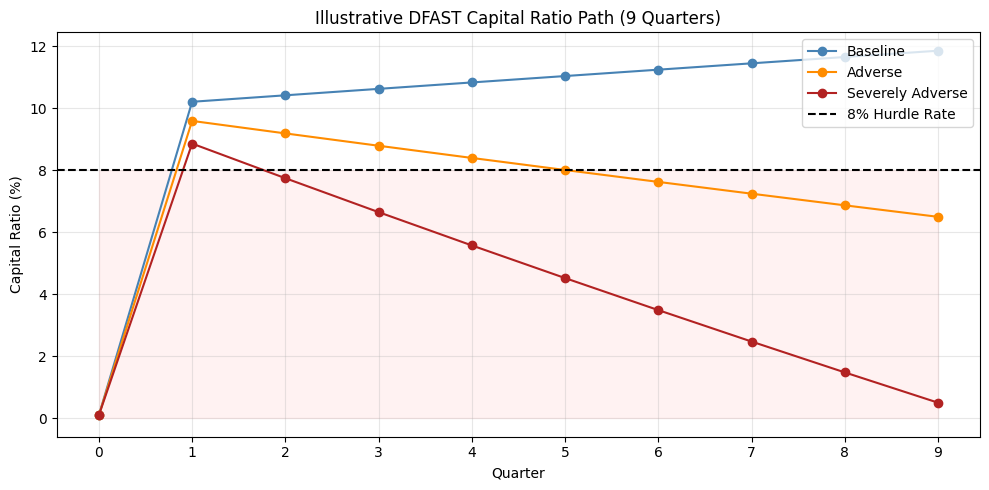

In [7]:
# Re-run all three scenarios to get full paths
from src.risk.regulatory import DFAST_ILLUSTRATIVE_SCENARIOS

fig, ax = plt.subplots(figsize=(10, 5))

colors = {'baseline': 'steelblue', 'adverse': 'darkorange', 'severely_adverse': 'firebrick'}

for scenario_name, params in DFAST_ILLUSTRATIVE_SCENARIOS.items():
    quarters = [
        StressQuarter(
            quarter=q + 1,
            credit_loss=params['credit_loss'],
            trading_loss=params['trading_loss'],
            counterparty_loss=params['counterparty_loss'],
            pre_provision_net_revenue=params['pre_provision_net_revenue'],
            provisions=params['provisions'],
            rwa_change=params['rwa_change'],
        )
        for q in range(9)
    ]
    path = project_capital_path(CapitalState(100.0, 1000.0), quarters)
    qs = [0] + [row['quarter'] for row in path]
    ratios = [100.0 / 1000.0] + [row['capital_ratio'] * 100 for row in path]
    ax.plot(qs, ratios, marker='o', label=scenario_name.replace('_', ' ').title(),
            color=colors[scenario_name])

ax.axhline(8.0, color='black', linestyle='--', lw=1.5, label='8% Hurdle Rate')
ax.fill_between(range(10), 0, 8.0, alpha=0.05, color='red')
ax.set_xlabel('Quarter')
ax.set_ylabel('Capital Ratio (%)')
ax.set_title('Illustrative DFAST Capital Ratio Path (9 Quarters)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(range(10))
plt.tight_layout()
plt.show()

## Section 7 — Validation Note

> **Disclaimer:** This is a **teaching engine**, not an official Federal Reserve DFAST model. The scenarios, loss rates, and capital projections are illustrative values used in MATH GR 5320 to demonstrate the mechanics of stress testing. Real DFAST scenarios are:
> - Published annually by the Federal Reserve
> - Multi-asset (28+ macroeconomic indicators)
> - Path-dependent with bank-specific loss functions
> - Subject to supervisory review and publication

**Formula-sheet §12 validation:**

| Function | Input | Expected |
|----------|-------|----------|
| `risk_weighted_assets([20,50,40],[0,1,0.2])` | — | 58.0 |
| `project_capital_one_quarter(s0, q1)` | capital=100, RWA=1000 | capital=94, RWA=1010 |
| `passes_stress(path, 0.08)` | baseline scenario | True |
| `passes_stress(path, 0.08)` | severely adverse, low capital | False |